## Requirements

### Dependencies

### Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from statistics import mode, StatisticsError

## Feature Extraction Pipeline

In [2]:
def extract_payload_length(info_string):
    """Extract payload length from Info column"""
    if pd.isna(info_string):
        return 0
    info_str = str(info_string)
    # Look for "Len=" in the Info field
    if "Len=" in info_str:
        try:
            # Extract the number after "Len="
            len_idx = info_str.find("Len=")
            len_str = info_str[len_idx+4:].split()[0]
            return int(len_str)
        except:
            return 0
    return 0


def extract_features(df_session):
    """
    Extract network traffic features from a session dataframe.
    
    Parameters:
    df_session: DataFrame with columns 'Time' and 'Length'
    
    Returns:
    Dictionary containing all extracted features
    """
    features = {}
    
    # 1. Packet count
    features['packet_count'] = len(df_session)
    
    # 2. Total length
    features['total_length'] = df_session['Length'].sum()
    
    # Packet intervals
    if len(df_session) > 1:
        time_diffs = df_session['Time'].diff().dropna().values
        features['avg_packet_interval'] = time_diffs.mean()
        features['max_packet_interval'] = time_diffs.max()
        
        # Most common packet interval
        try:
            features['most_common_packet_interval'] = mode(time_diffs)
        except StatisticsError:
            features['most_common_packet_interval'] = np.nan
    else:
        features['avg_packet_interval'] = 0
        features['max_packet_interval'] = 0
        features['most_common_packet_interval'] = 0
    
    # Packet length statistics
    features['avg_packet_length'] = df_session['Length'].mean()
    features['max_packet_length'] = df_session['Length'].max()
    features['min_packet_length'] = df_session['Length'].min()
    
    # Most common packet length
    try:
        features['most_common_packet_length'] = mode(df_session['Length'].values)
    except StatisticsError:
        # If there's no mode (all unique), use 0 or NaN
        features['most_common_packet_length'] = np.nan
    
    # Payload and header statistics
    df_session['payload_length'] = df_session['Info'].apply(extract_payload_length)
    features['avg_payload_length'] = df_session['payload_length'].mean()
    
    df_session['header_length'] = df_session['Length'] - df_session['payload_length']
    features['avg_header_length'] = df_session['header_length'].mean()
    
    return features


def load_and_process_sessions(data_dir='data'):
    """
    Load all network session CSV files matching pattern networkname_number.csv
    and extract features for each session.
    
    Parameters:
    data_dir: Directory containing the CSV files
    
    Returns:
    DataFrame with one row per session and columns for each feature
    """
    data_path = Path(data_dir)
    csv_files = sorted(data_path.glob('*_*.csv'))
    
    all_features = []
    
    for csv_file in csv_files:
        try:
            # Load the session
            df = pd.read_csv(csv_file)
            
            # Extract network name and session number from filename
            filename = csv_file.stem  # removes .csv extension
            parts = filename.rsplit('_', 1)  # split from the right on last _
            if len(parts) == 2:
                network_name, session_num = parts
            else:
                network_name = filename
                session_num = None
            
            # Convert Time column to numeric and sort by time
            df['Time'] = pd.to_numeric(df['Time'])
            df = df.sort_values('Time').reset_index(drop=True)
            
            # Extract features
            features = extract_features(df)
            features['network'] = network_name
            features['session'] = session_num
            
            all_features.append(features)
            print(f"Processed: {csv_file.name}")
            
        except Exception as e:
            print(f"Error processing {csv_file.name}: {e}")
    
    # Create DataFrame from all features
    features_df = pd.DataFrame(all_features)
    return features_df


# Load and process all sessions
df_features = load_and_process_sessions('data')

Processed: colonialwilliamsburg_01.csv
Processed: colonialwilliamsburg_02.csv
Processed: colonialwilliamsburg_03.csv
Processed: colonialwilliamsburg_04.csv
Processed: colonialwilliamsburg_05.csv
Processed: colonialwilliamsburg_06.csv
Processed: colonialwilliamsburg_07.csv
Processed: colonialwilliamsburg_08.csv
Processed: colonialwilliamsburg_09.csv
Processed: colonialwilliamsburg_10.csv
Processed: colonialwilliamsburg_11.csv
Processed: colonialwilliamsburg_12.csv
Processed: colonialwilliamsburg_13.csv
Processed: colonialwilliamsburg_14.csv
Processed: colonialwilliamsburg_15.csv
Processed: colonialwilliamsburg_16.csv
Processed: colonialwilliamsburg_17.csv
Processed: colonialwilliamsburg_18.csv
Processed: colonialwilliamsburg_19.csv
Processed: colonialwilliamsburg_20.csv
Processed: colonialwilliamsburg_21.csv
Processed: colonialwilliamsburg_22.csv
Processed: colonialwilliamsburg_23.csv
Processed: colonialwilliamsburg_24.csv
Processed: colonialwilliamsburg_25.csv
Processed: colonialwillia

In [3]:
df_features.to_csv("data/packet_data.csv", index=False)

In [4]:
df_features.head()

,packet_count,total_length,avg_packet_interval,max_packet_interval,most_common_packet_interval,avg_packet_length,max_packet_length,min_packet_length,most_common_packet_length,avg_payload_length,avg_header_length,network,session
0,798,378701,0.073880,6.060027,1.000000e-06,474.562657,1514,54,66,214.834586,259.728070,colonialwilliamsburg,01
1,554,231689,0.091706,5.009707,3.000000e-06,418.211191,1514,54,66,245.261733,172.949458,colonialwilliamsburg,02
2,559,234630,0.105295,10.030999,3.000000e-06,419.731664,1514,54,66,251.377460,168.354204,colonialwilliamsburg,03
3,231,70556,0.240017,11.117093,3.000000e-06,305.437229,1514,54,66,143.528139,161.909091,colonialwilliamsburg,04
4,93,14414,0.587726,11.968261,3.000000e-06,154.989247,1454,54,66,30.182796,124.806452,colonialwilliamsburg,05


In [5]:
X = df_features.drop(columns=['network', 'session'])
y = df_features['network']

# Splitting Datasets

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# 6:2:2 split with balanced network source distribution
# currently set with random state seed of 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain network distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation network distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest network distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (72, 11)
Validation shape: (24, 11)
Test shape: (24, 11)

Train network distribution:
network
instagram               0.333333
target                  0.333333
colonialwilliamsburg    0.333333
Name: proportion, dtype: float64

Validation network distribution:
network
target                  0.333333
instagram               0.333333
colonialwilliamsburg    0.333333
Name: proportion, dtype: float64

Test network distribution:
network
colonialwilliamsburg    0.333333
target                  0.333333
instagram               0.333333
Name: proportion, dtype: float64


In [8]:
X.columns

Index(['packet_count', 'total_length', 'avg_packet_interval',
       'max_packet_interval', 'most_common_packet_interval',
       'avg_packet_length', 'max_packet_length', 'min_packet_length',
       'most_common_packet_length', 'avg_payload_length', 'avg_header_length'],
      dtype='str')

In [9]:
import seaborn as sns

import matplotlib.pyplot as plt

## Model Testing and Comparison Framework

In [10]:
# Model imports and preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Initialize results storage
model_results = {}

In [11]:
# Evaluation utilities
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    """
    Comprehensive model evaluation on train, validation, and test sets.
    
    Returns dictionary with all metrics for comparison.
    """
    results = {
        'model': model_name,
        'train': {},
        'validation': {},
        'test': {}
    }
    
    # Evaluate on each set
    for set_name, (X, y) in [('train', (X_train, y_train)), 
                              ('validation', (X_val, y_val)), 
                              ('test', (X_test, y_test))]:
        y_pred = model.predict(X)
        
        results[set_name]['accuracy'] = accuracy_score(y, y_pred)
        results[set_name]['precision_weighted'] = precision_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['recall_weighted'] = recall_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['f1_weighted'] = f1_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['f1_macro'] = f1_score(y, y_pred, average='macro', zero_division=0)
    
    return results

def print_model_results(results):
    """Pretty print model evaluation results"""
    model_name = results['model']
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    for set_name in ['train', 'validation', 'test']:
        print(f"\n{set_name.upper()} SET:")
        for metric, value in results[set_name].items():
            print(f"  {metric:20s}: {value:.4f}")


### 1. Random Forest Classifier

In [12]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest
rf_results = evaluate_model(rf_model, X_train, X_val, X_test, y_train, y_val, y_test, "Random Forest")
model_results['Random Forest'] = rf_results
print_model_results(rf_results)

# Feature importance
print("\nTop 10 Most Important Features (Random Forest):")
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importance.head(10))

Training Random Forest...

Model: Random Forest

TRAIN SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000

VALIDATION SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000

TEST SET:
  accuracy            : 0.9583
  precision_weighted  : 0.9630
  recall_weighted     : 0.9583
  f1_weighted         : 0.9582
  f1_macro            : 0.9582

Top 10 Most Important Features (Random Forest):
max_packet_length              0.193836
min_packet_length              0.191636
most_common_packet_length      0.186909
most_common_packet_interval    0.151491
avg_header_length              0.095978
packet_count                   0.041538
avg_packet_interval            0.033679
avg_packet_length              0.029046
total_length                   0.025886
max_packet_interval            0.02505

### 2. Logistic Regression (Multiclass)

In [13]:
# Scale features for Logistic Regression
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)
X_test_scaled = scaler_lr.transform(X_test)

print("Training Logistic Regression (Multiclass)...")

# Compatibility handling across scikit-learn versions:
# - Older versions accept explicit multi_class='multinomial'.
# - Newer versions removed the multi_class argument.
try:
    lg_model = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
except TypeError:
    lg_model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

lg_model.fit(X_train_scaled, y_train)

# Evaluate Logistic Regression
lg_results = evaluate_model(
    lg_model,
    X_train_scaled,
    X_val_scaled,
    X_test_scaled,
    y_train,
    y_val,
    y_test,
    "Logistic Regression"
)
model_results['Logistic Regression'] = lg_results
print_model_results(lg_results)

Training Logistic Regression (Multiclass)...

Model: Logistic Regression

TRAIN SET:
  accuracy            : 0.9583
  precision_weighted  : 0.9599
  recall_weighted     : 0.9583
  f1_weighted         : 0.9583
  f1_macro            : 0.9583

VALIDATION SET:
  accuracy            : 0.9583
  precision_weighted  : 0.9630
  recall_weighted     : 0.9583
  f1_weighted         : 0.9582
  f1_macro            : 0.9582

TEST SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000


### 3. Support Vector Machine (SVM)

In [14]:
# SVM also needs scaled features
print("Training Support Vector Machine (SVM)...")
svm_model = SVC(
    kernel='rbf',  # RBF kernel generally works well
    C=1.0,
    gamma='scale',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

# Evaluate SVM
svm_results = evaluate_model(svm_model, X_train_scaled, X_val_scaled, X_test_scaled, 
                             y_train, y_val, y_test, "Support Vector Machine")
model_results['Support Vector Machine'] = svm_results
print_model_results(svm_results)

Training Support Vector Machine (SVM)...

Model: Support Vector Machine

TRAIN SET:
  accuracy            : 0.9722
  precision_weighted  : 0.9744
  recall_weighted     : 0.9722
  f1_weighted         : 0.9722
  f1_macro            : 0.9722

VALIDATION SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9185
  f1_macro            : 0.9185

TEST SET:
  accuracy            : 0.8750
  precision_weighted  : 0.9091
  recall_weighted     : 0.8750
  f1_weighted         : 0.8704
  f1_macro            : 0.8704


### 4. TensorFlow/Keras Neural Network

In [15]:
# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical (one-hot encoding)
y_train_cat = keras.utils.to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))
y_val_cat = keras.utils.to_categorical(y_val_encoded, num_classes=len(label_encoder.classes_))
y_test_cat = keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

print(f"\nNumber of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_}")
print(f"y_train_cat shape: {y_train_cat.shape}")

# Build neural network model
print("\nBuilding Neural Network Model...")
nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(nn_model.summary())

TensorFlow version: 2.19.1

Number of classes: 3
Classes: ['colonialwilliamsburg' 'instagram' 'target']
y_train_cat shape: (72, 3)

Building Neural Network Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971 (46.76 KB)

 Trainable params: 11,971 (46.76 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# Train neurał network
print("Training Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=16,
    verbose=1
)

# Evaluate Neural Network on test set
print("\nEvaluating Neural Network on Test Set...")
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions for detailed metrics
y_train_pred = np.argmax(nn_model.predict(X_train_scaled, verbose=0), axis=1)
y_val_pred = np.argmax(nn_model.predict(X_val_scaled, verbose=0), axis=1)
y_test_pred = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)

# Decode predictions back to original labels
y_train_pred_labels = label_encoder.inverse_transform(y_train_pred)
y_val_pred_labels = label_encoder.inverse_transform(y_val_pred)
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Store NN results manually (since model format is different)
nn_results = {
    'model': 'Neural Network',
    'train': {
        'accuracy': accuracy_score(y_train, y_train_pred_labels),
        'precision_weighted': precision_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_train, y_train_pred_labels, average='macro', zero_division=0)
    },
    'validation': {
        'accuracy': accuracy_score(y_val, y_val_pred_labels),
        'precision_weighted': precision_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_val, y_val_pred_labels, average='macro', zero_division=0)
    },
    'test': {
        'accuracy': accuracy_score(y_test, y_test_pred_labels),
        'precision_weighted': precision_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_test, y_test_pred_labels, average='macro', zero_division=0)
    }
}

model_results['Neural Network'] = nn_results
print_model_results(nn_results)

Training Neural Network...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3056 - loss: 1.1161 - val_accuracy: 0.5833 - val_loss: 1.0074
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3889 - loss: 1.0206 - val_accuracy: 0.8750 - val_loss: 0.9424
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5833 - loss: 0.9697 - val_accuracy: 0.9167 - val_loss: 0.8730
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7222 - loss: 0.8786 - val_accuracy: 0.9583 - val_loss: 0.7988
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6806 - loss: 0.8849 - val_accuracy: 0.9167 - val_loss: 0.7224
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7222 - loss: 0.7958 - val_accuracy: 0.9167 - val_loss: 0.6484
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8333 - loss: 0.6856 - val_accuracy: 0.9167 - val_loss: 0.5751
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8472 - loss: 0.6436 - val_a

## Feature Interdependency Analysis

Evaluate feature correlations and multicollinearity to determine if feature selection improves model performance.


FEATURE INTERDEPENDENCY ANALYSIS

1. CORRELATION MATRIX
------------------------------------------------------------------------------------------


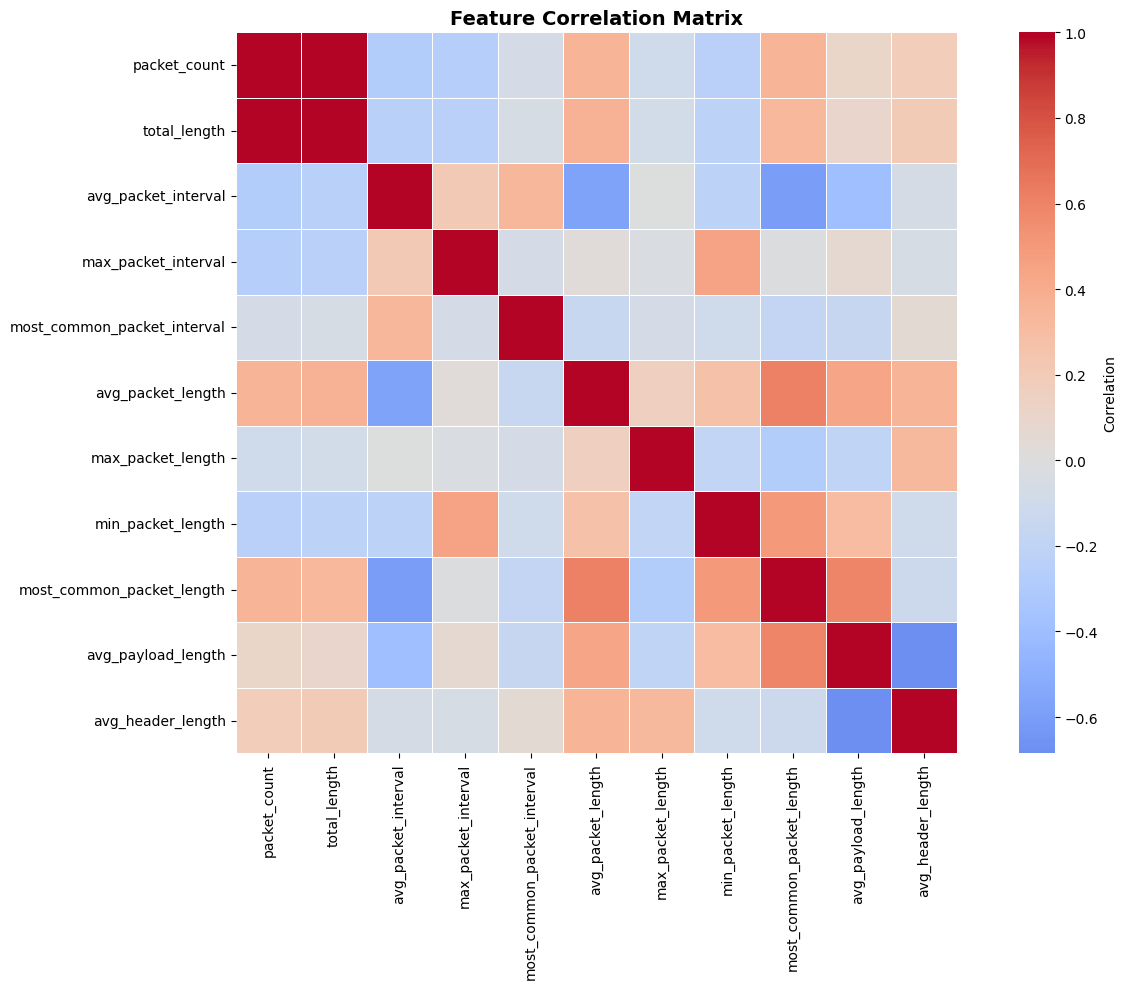


2. RANDOM FOREST FEATURE IMPORTANCE
------------------------------------------------------------------------------------------
max_packet_length              0.193836
min_packet_length              0.191636
most_common_packet_length      0.186909
most_common_packet_interval    0.151491
avg_header_length              0.095978
packet_count                   0.041538
avg_packet_interval            0.033679
avg_packet_length              0.029046
total_length                   0.025886
max_packet_interval            0.025055
avg_payload_length             0.024945
dtype: float64


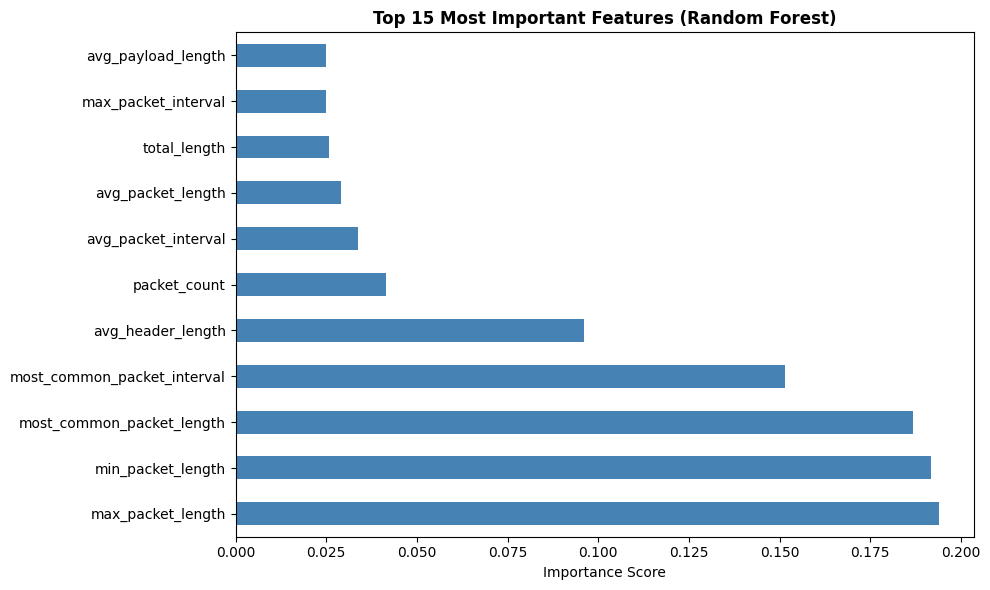


3. HIGH CORRELATION PAIRS (|r| > 0.7)
------------------------------------------------------------------------------------------
Found 1 pairs with |correlation| > 0.7:
   Feature 1    Feature 2  Correlation
packet_count total_length      0.99654

4. VARIANCE INFLATION FACTOR (VIF) - Multicollinearity
------------------------------------------------------------------------------------------
VIF Interpretation:
  VIF = 1:     No correlation with other features
  VIF < 5:     Low multicollinearity (generally acceptable)
  VIF >= 5:    Moderate to high multicollinearity (consider removing)
  VIF >= 10:   High multicollinearity (should remove or combine)

                    Feature        VIF
         avg_payload_length        inf
          avg_header_length        inf
          avg_packet_length        inf
               packet_count 182.097187
               total_length 174.749458
          min_packet_length  25.524366
  most_common_packet_length   6.380648
        max_packet_interval

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 90)
print("FEATURE INTERDEPENDENCY ANALYSIS")
print("=" * 90)

# 1. Correlation Matrix
print("\n1. CORRELATION MATRIX")
print("-" * 90)
correlation_matrix = X_train.corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, 
            ax=ax, cbar_kws={'label': 'Correlation'}, annot=False, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Feature Importance from Random Forest
print("\n2. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 90)
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importance)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. High Correlation Pairs
print("\n3. HIGH CORRELATION PAIRS (|r| > 0.7)")
print("-" * 90)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f"Found {len(high_corr_df)} pairs with |correlation| > 0.7:")
    print(high_corr_df.to_string(index=False))
else:
    print("No feature pairs found with |correlation| > 0.7")

# 4. Variance Inflation Factor (VIF) - Multicollinearity Check
print("\n4. VARIANCE INFLATION FACTOR (VIF) - Multicollinearity")
print("-" * 90)
print("VIF Interpretation:")
print("  VIF = 1:     No correlation with other features")
print("  VIF < 5:     Low multicollinearity (generally acceptable)")
print("  VIF >= 5:    Moderate to high multicollinearity (consider removing)")
print("  VIF >= 10:   High multicollinearity (should remove or combine)\n")

vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

# Highlight problematic features
high_vif = vif_data[vif_data['VIF'] >= 5]
if len(high_vif) > 0:
    print(f"\n⚠️  {len(high_vif)} features have VIF >= 5 (potential multicollinearity):")
    for idx, row in high_vif.iterrows():
        print(f"    - {row['Feature']}: VIF = {row['VIF']:.2f}")
else:
    print("\n✓ All features have VIF < 5 (low multicollinearity)")

# 5. Feature Redundancy Analysis
print("\n5. REDUNDANT FEATURE ANALYSIS")
print("-" * 90)
print("Features with low importance (< 1% of total) and high correlation with others:\n")

# Calculate cumulative importance
total_importance = feature_importance.sum()
cumulative_importance = feature_importance.cumsum() / total_importance

# Find low-importance features
low_importance_threshold = 0.01
low_importance_features = feature_importance[feature_importance / total_importance < low_importance_threshold]

redundant_candidates = []
for feat in low_importance_features.index:
    corr_values = correlation_matrix[feat].abs().sort_values(ascending=False)
    max_corr_other = corr_values[1]  # exclude self-correlation
    
    if max_corr_other > 0.5:
        redundant_candidates.append({
            'Feature': feat,
            'Importance': feature_importance[feat],
            'Max Correlation': max_corr_other,
            'Correlated With': corr_values[corr_values != 1.0].index[0]
        })

if redundant_candidates:
    redundant_df = pd.DataFrame(redundant_candidates).sort_values('Max Correlation', ascending=False)
    print(redundant_df.to_string(index=False))
    print(f"\nThese {len(redundant_df)} features may be redundant candidates for removal.")
else:
    print("No clear redundant features identified.")

# 6. Summary and Recommendations
print("\n" + "=" * 90)
print("RECOMMENDATIONS FOR FEATURE SELECTION")
print("=" * 90)

# Number of features needed to explain 95% of variance
features_95 = (cumulative_importance <= 0.95).sum()
features_90 = (cumulative_importance <= 0.90).sum()

print(f"\nFeature Count Summary:")
print(f"  Total features: {len(X_train.columns)}")
print(f"  Features for 90% importance: {features_90}")
print(f"  Features for 95% importance: {features_95}")
print(f"  Potential reduction: {len(X_train.columns) - features_95} features")

print("\nRecommendations:")

if len(high_corr_df) > 0 if high_corr_pairs else len(high_corr_pairs) > 0:
    print("  1. HIGH CORRELATION: Remove one feature from each highly correlated pair")
    for idx, row in high_corr_df.iterrows() if high_corr_pairs else []:
        less_important = row['Feature 1'] if feature_importance[row['Feature 1']] < feature_importance[row['Feature 2']] else row['Feature 2']
        print(f"     Consider removing: {less_important}")

if len(high_vif) > 0:
    print(f"  2. MULTICOLLINEARITY: {len(high_vif)} features have high VIF scores")
    print(f"     Consider using PCA or selecting top {features_95} features by importance")

if len(redundant_candidates) > 0:
    print(f"  3. REDUNDANCY: {len(redundant_candidates)} low-importance features are highly correlated with others")
    for feat in low_importance_features.index[:5]:
        print(f"     Consider removing: {feat}")

print(f"\n  4. DIMENSIONALITY REDUCTION: Consider training with top {features_95}-{features_90} features")
print(f"     This could improve:")
print(f"     - Model training speed")
print(f"     - Reduced overfitting risk")
print(f"     - Interpretability")
print(f"     - Potential performance gains")

print("\n  5. NEXT STEPS:")
print(f"     Option A: Re-run models with selected features (top {features_95} by importance)")
print(f"     Option B: Use dimensionality reduction (PCA) before training")
print(f"     Option C: Use regularization (L1/Lasso) to automatically select features")


## Model Comparison and Results

In [17]:
# Create comprehensive comparison dataframe
comparison_data = []

for model_name, results in model_results.items():
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': results['train']['accuracy'],
        'Val Accuracy': results['validation']['accuracy'],
        'Test Accuracy': results['test']['accuracy'],
        'Train F1': results['train']['f1_weighted'],
        'Val F1': results['validation']['f1_weighted'],
        'Test F1': results['test']['f1_weighted'],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Focus on test set performance
print("\n" + "="*80)
print("TEST SET PERFORMANCE RANKING")
print("="*80)
test_ranking = comparison_df[['Model', 'Test Accuracy', 'Test F1']].sort_values('Test Accuracy', ascending=False)
print(test_ranking.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON
                 Model  Train Accuracy  Val Accuracy  Test Accuracy  Train F1   Val F1  Test F1
         Random Forest        1.000000      1.000000       0.958333  1.000000 1.000000 0.958170
   Logistic Regression        0.958333      0.958333       1.000000  0.958298 0.958170 1.000000
Support Vector Machine        0.972222      0.916667       0.875000  0.972174 0.918519 0.870445
        Neural Network        1.000000      0.958333       1.000000  1.000000 0.958170 1.000000

TEST SET PERFORMANCE RANKING
                 Model  Test Accuracy  Test F1
   Logistic Regression       1.000000 1.000000
        Neural Network       1.000000 1.000000
         Random Forest       0.958333 0.958170
Support Vector Machine       0.875000 0.870445


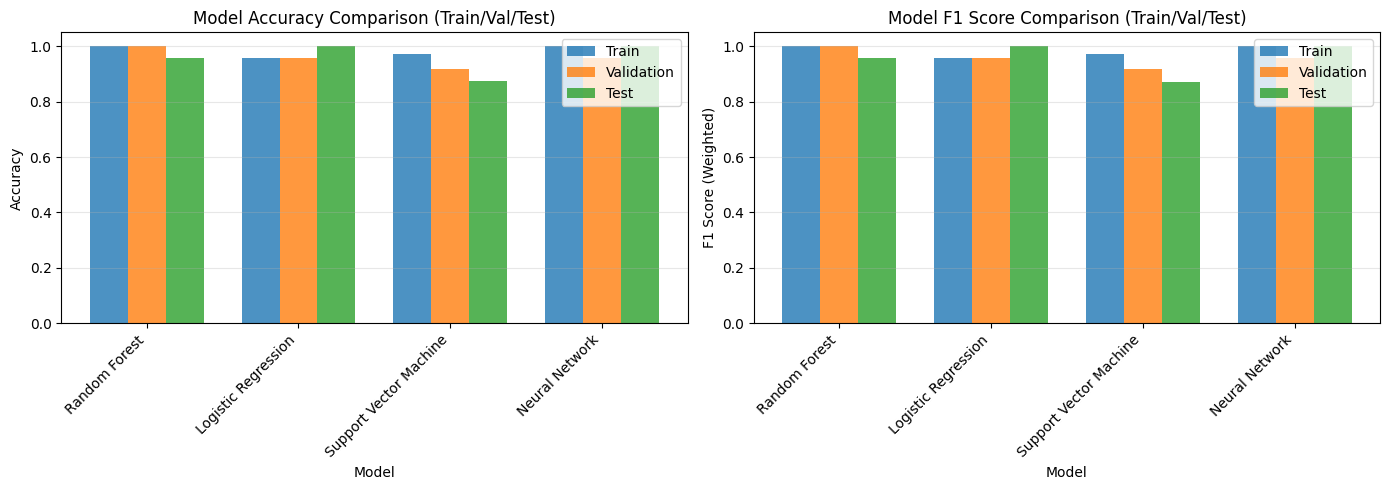

Visualizations saved!


In [18]:
# Visualization: Model Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy across datasets
models = comparison_df['Model'].tolist()
x_pos = np.arange(len(models))
width = 0.25

axes[0].bar(x_pos - width, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
axes[0].bar(x_pos, comparison_df['Val Accuracy'], width, label='Validation', alpha=0.8)
axes[0].bar(x_pos + width, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison (Train/Val/Test)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: F1 Score comparison
axes[1].bar(x_pos - width, comparison_df['Train F1'], width, label='Train', alpha=0.8)
axes[1].bar(x_pos, comparison_df['Val F1'], width, label='Validation', alpha=0.8)
axes[1].bar(x_pos + width, comparison_df['Test F1'], width, label='Test', alpha=0.8)

axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Model F1 Score Comparison (Train/Val/Test)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations saved!")

### Detailed Classification Reports

In [19]:
# Function to print detailed classification report
def print_detailed_report(y_true, y_pred, model_name, dataset_name):
    """Print detailed classification report including per-class metrics"""
    print(f"\n{'='*70}")
    print(f"{model_name} - {dataset_name} Set Classification Report")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred))

# Get predictions for all models on test set
print("\n\n" + "="*80)
print("DETAILED TEST SET ANALYSIS")
print("="*80)

# Random Forest
rf_test_pred = rf_model.predict(X_test)
print_detailed_report(y_test, rf_test_pred, "Random Forest", "Test")

# Logistic Regression
lg_test_pred = lg_model.predict(X_test_scaled)
print_detailed_report(y_test, lg_test_pred, "Logistic Regression", "Test")

# SVM
svm_test_pred = svm_model.predict(X_test_scaled)
print_detailed_report(y_test, svm_test_pred, "Support Vector Machine", "Test")

# Neural Network
print_detailed_report(y_test, y_test_pred_labels, "Neural Network", "Test")



DETAILED TEST SET ANALYSIS

Random Forest - Test Set Classification Report
                      precision    recall  f1-score   support

colonialwilliamsburg       1.00      1.00      1.00         8
           instagram       1.00      0.88      0.93         8
              target       0.89      1.00      0.94         8

            accuracy                           0.96        24
           macro avg       0.96      0.96      0.96        24
        weighted avg       0.96      0.96      0.96        24


Logistic Regression - Test Set Classification Report
                      precision    recall  f1-score   support

colonialwilliamsburg       1.00      1.00      1.00         8
           instagram       1.00      1.00      1.00         8
              target       1.00      1.00      1.00         8

            accuracy                           1.00        24
           macro avg       1.00      1.00      1.00        24
        weighted avg       1.00      1.00      1.00       

### Confusion Matrices

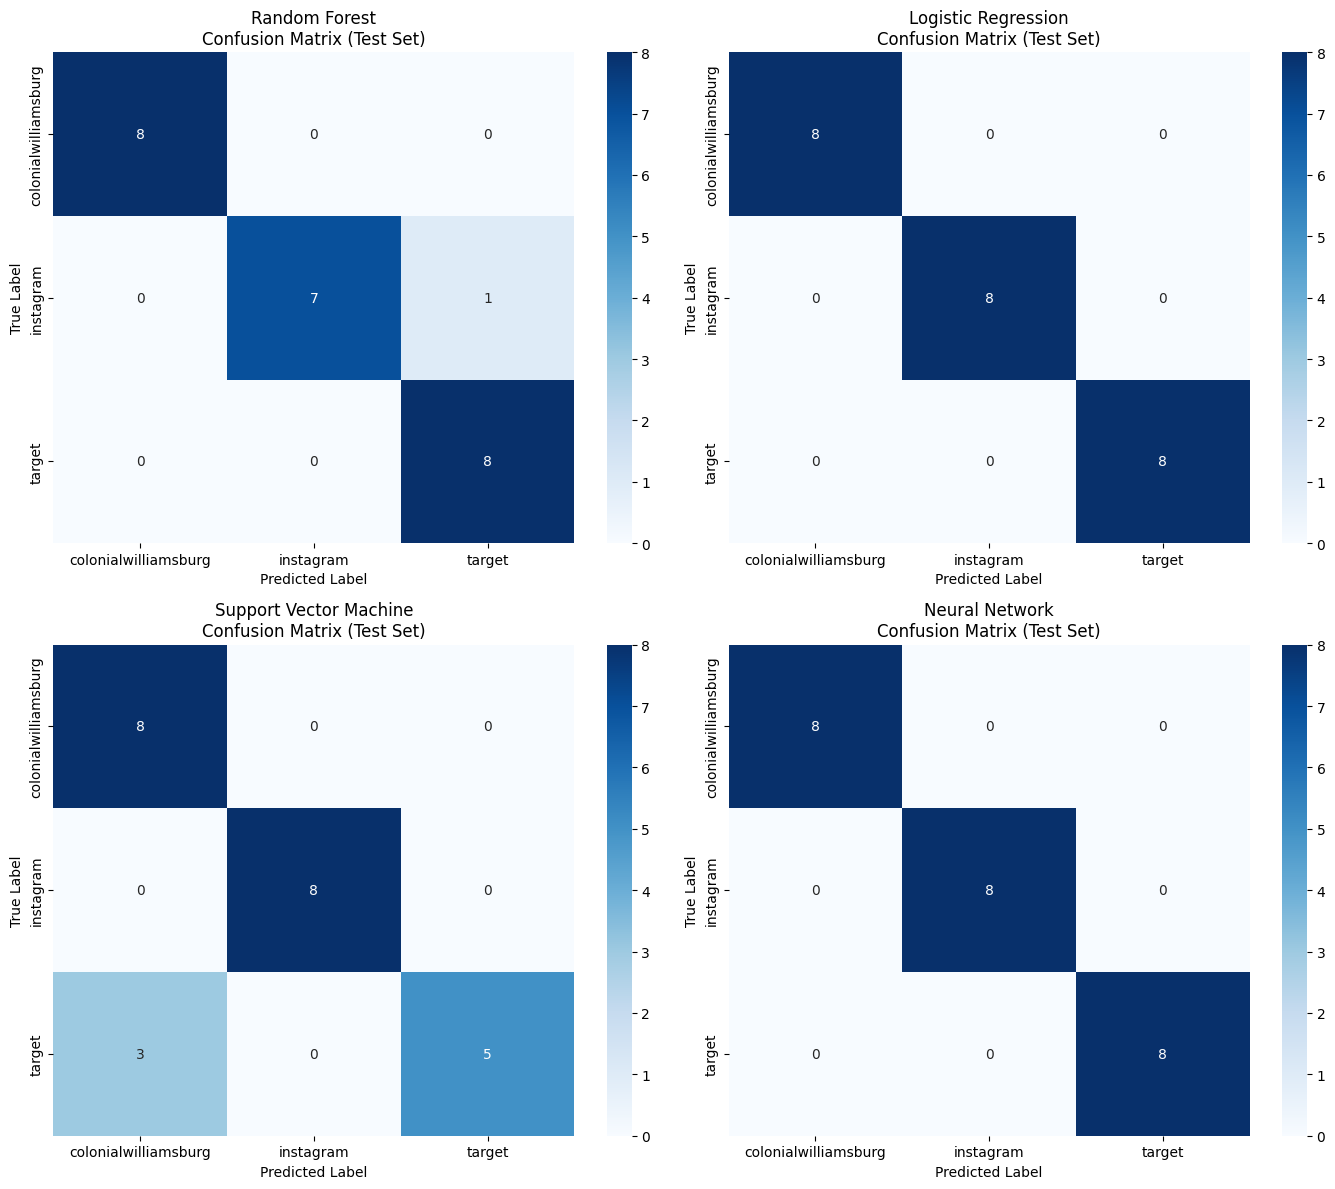

Confusion matrices generated!


In [20]:
# Visualize confusion matrices for best performing models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Get predictions
predictions = {
    'Random Forest': rf_test_pred,
    'Logistic Regression': lg_test_pred,
    'Support Vector Machine': svm_test_pred,
    'Neural Network': y_test_pred_labels
}

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    ax.set_title(f'{model_name}\nConfusion Matrix (Test Set)')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion matrices generated!")

## Summary and Recommendations

In [21]:
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

# Find best model by test accuracy
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_test_acc = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n✓ BEST PERFORMING MODEL: {best_model_name}")
print(f"  Test Accuracy: {best_test_acc:.4f}")

# Check for overfitting/underfitting
print("\n✓ OVERFITTING/UNDERFITTING ANALYSIS:")
for idx, row in comparison_df.iterrows():
    train_acc = row['Train Accuracy']
    test_acc = row['Test Accuracy']
    gap = train_acc - test_acc
    model_name = row['Model']
    
    if gap > 0.1:
        status = "OVERFITTING DETECTED"
    elif gap < -0.05:
        status = "UNDERFITTING DETECTED"
    else:
        status = "GOOD GENERALIZATION"
    
    print(f"  {model_name:25s}: Gap={gap:.4f} -> {status}")

print("\n✓ KEY OBSERVATIONS:")
print(f"  - Number of classes: {len(label_encoder.classes_)}")
print(f"  - Training set size: {len(X_train)}")
print(f"  - Validation set size: {len(X_val)}")
print(f"  - Test set size: {len(X_test)}")
print(f"  - Number of features: {X_train.shape[1]}")

print("\n✓ RECOMMENDATIONS FOR IMPROVEMENT:")
recommendations = [
    "1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV for better parameters",
    "2. Feature Engineering: Create new features or perform feature selection",
    "3. Class Balancing: Check if classes are imbalanced and use appropriate techniques",
    "4. Ensemble Methods: Combine multiple models (voting, stacking) for better performance",
    "5. Deep Learning: Try more complex neural architectures (Conv1D, LSTM, Attention)",
    "6. Cross-Validation: Implement k-fold cross-validation for robust evaluation"
]

for rec in recommendations:
    print(f"  {rec}")


ANALYSIS SUMMARY

✓ BEST PERFORMING MODEL: Logistic Regression
  Test Accuracy: 1.0000

✓ OVERFITTING/UNDERFITTING ANALYSIS:
  Random Forest            : Gap=0.0417 -> GOOD GENERALIZATION
  Logistic Regression      : Gap=-0.0417 -> GOOD GENERALIZATION
  Support Vector Machine   : Gap=0.0972 -> GOOD GENERALIZATION
  Neural Network           : Gap=0.0000 -> GOOD GENERALIZATION

✓ KEY OBSERVATIONS:
  - Number of classes: 3
  - Training set size: 72
  - Validation set size: 24
  - Test set size: 24
  - Number of features: 11

✓ RECOMMENDATIONS FOR IMPROVEMENT:
  1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV for better parameters
  2. Feature Engineering: Create new features or perform feature selection
  3. Class Balancing: Check if classes are imbalanced and use appropriate techniques
  4. Ensemble Methods: Combine multiple models (voting, stacking) for better performance
  5. Deep Learning: Try more complex neural architectures (Conv1D, LSTM, Attention)
  6. Cross-Val

## Leakage and Robustness Diagnostics

These checks help explain suspiciously high or identical train/validation/test scores.

- Split health and class balance
- Feature overlap across splits (possible leakage)
- Label-shuffle sanity test
- 5-fold cross-validation estimate

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils import shuffle

print("=" * 90)
print("DIAGNOSTIC 1: SPLIT HEALTH AND CLASS BALANCE")
print("=" * 90)

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

print("\nClass proportions by split:")
print("Train:\n", y_train.value_counts(normalize=True).sort_index())
print("\nValidation:\n", y_val.value_counts(normalize=True).sort_index())
print("\nTest:\n", y_test.value_counts(normalize=True).sort_index())

print("\nLikely meaning:")
print("- Similar class proportions across splits suggest stratification worked as intended.")
print("- Very small validation/test sets can make metrics look unstable or coincidentally identical.")


print("\n" + "=" * 90)
print("DIAGNOSTIC 2: FEATURE OVERLAP ACROSS SPLITS (POSSIBLE LEAKAGE)")
print("=" * 90)

# Round to reduce tiny floating-point differences before tuple conversion.
train_rows = set(map(tuple, X_train.round(10).to_numpy()))
val_rows = set(map(tuple, X_val.round(10).to_numpy()))
test_rows = set(map(tuple, X_test.round(10).to_numpy()))

overlap_train_val = len(train_rows & val_rows)
overlap_train_test = len(train_rows & test_rows)
overlap_val_test = len(val_rows & test_rows)

total_overlap = overlap_train_val + overlap_train_test + overlap_val_test

print(f"Exact feature-row overlap Train∩Val:  {overlap_train_val}")
print(f"Exact feature-row overlap Train∩Test: {overlap_train_test}")
print(f"Exact feature-row overlap Val∩Test:   {overlap_val_test}")

print("\nLikely meaning:")
if total_overlap > 0:
    print("- Non-zero overlap indicates duplicate/near-duplicate feature rows across splits.")
    print("- This can leak information and inflate validation/test performance.")
else:
    print("- No exact feature-row overlap found across splits.")
    print("- This lowers leakage risk from literal duplicate rows (but does not rule out all leakage).")


print("\n" + "=" * 90)
print("DIAGNOSTIC 3: SHUFFLED-LABEL SANITY TEST")
print("=" * 90)

# If labels are shuffled, a clean pipeline should collapse near chance performance.
y_train_shuf = shuffle(y_train, random_state=42)

rf_sanity = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sanity.fit(X_train, y_train_shuf)

sanity_train_acc = rf_sanity.score(X_train, y_train_shuf)
sanity_val_acc = rf_sanity.score(X_val, y_val)
sanity_test_acc = rf_sanity.score(X_test, y_test)
chance_level = 1 / y.nunique()

print(f"Shuffled-label train accuracy: {sanity_train_acc:.4f}")
print(f"Shuffled-label val accuracy:   {sanity_val_acc:.4f}")
print(f"Shuffled-label test accuracy:  {sanity_test_acc:.4f}")
print(f"Approximate chance level:      {chance_level:.4f}")

print("\nLikely meaning:")
if sanity_val_acc > chance_level + 0.15 or sanity_test_acc > chance_level + 0.15:
    print("- Validation/test accuracy remains well above chance even with shuffled labels.")
    print("- This strongly suggests leakage or a pipeline bug.")
else:
    print("- Validation/test performance near chance is expected after shuffling labels.")
    print("- This is a good sign that the pipeline is not trivially leaking target information.")


print("\n" + "=" * 90)
print("DIAGNOSTIC 4: 5-FOLD CROSS-VALIDATION ROBUSTNESS")
print("=" * 90)

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cv, X, y, cv=cv, scoring='accuracy')

print("Fold accuracies:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std CV accuracy:  {cv_scores.std():.4f}")

print("\nLikely meaning:")
print("- CV mean is usually a more stable estimate than a single holdout split.")
if cv_scores.mean() < 0.9:
    print("- If CV is notably lower than your holdout result, your original split may be optimistic.")
elif cv_scores.std() > 0.08:
    print("- Large fold-to-fold variance suggests limited sample size and unstable estimates.")
else:
    print("- High and stable CV supports that the task may genuinely be easy for current features.")

print("\n" + "=" * 90)
print("DIAGNOSTIC SUMMARY")
print("=" * 90)
if total_overlap > 0 or (sanity_val_acc > chance_level + 0.15 or sanity_test_acc > chance_level + 0.15):
    print("High-confidence warning: potential leakage detected. Investigate split construction and feature generation.")
elif cv_scores.mean() > 0.95 and cv_scores.std() < 0.05:
    print("Pipeline appears clean and performance may truly be strong for this dataset.")
else:
    print("No hard leakage signal found, but results should be treated with caution due to dataset size and variance.")